In [148]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

In [124]:
def european_call_payoff (S:float, K:float) -> float:
    return max(S - K, 0.0)

In [125]:
def create_spot_tree_balanced (spot: float, spot_mult_up: float, discount_factor: float, steps: int) -> list[list[float]]:
    spot_mult_down = (2*(1/discount_factor))- spot_mult_up
    previous_level = [spot]
    tree = [previous_level]
    for _ in range(steps):
        new_level = [s * spot_mult_down for s in previous_level]
        new_level += [previous_level[-1] * spot_mult_up]
        tree += [new_level]
        previous_level = new_level
    return tree


In [126]:
spot = 100
spot_mult_up = 1.02
discount_factor = 1
steps = 3
spot_tree = create_spot_tree_balanced(spot, spot_mult_up, discount_factor, steps)
spot_tree_readable = [['%.3f' % e for e in n] for n in spot_tree]
print(spot_tree_readable)

[['100.000'], ['98.000', '102.000'], ['96.040', '99.960', '104.040'], ['94.119', '97.961', '101.959', '106.121']]


In [127]:
def create_balanced_discounted_price_tree (spot_tree: list[list[float]], discount_factor: float, K: float) -> list[list[float]]:
    spot = spot_tree[0][0]
    spot_mult_up = spot_tree[1][-1] / spot
    spot_mult_down = spot_tree[1][0] / spot
    p_rf = ((1/discount_factor)-spot_mult_down)/(spot_mult_up-spot_mult_down)
    q_rf = 1-p_rf
    steps = len(spot_tree) - 1

    continuation_value_tree = [[np.nan for _ in level] for level in spot_tree]

    for i in range (len(spot_tree[-1])):
        spot = spot_tree[-1][i]
        discounted_continuation_value = european_call_payoff(spot,K)
        continuation_value_tree[-1][i] = discounted_continuation_value

    for step in range(steps -1, -1, -1):
        for i in range(len(spot_tree[step])):
            expected_value = p_rf * continuation_value_tree[step + 1][i] + q_rf * continuation_value_tree[step + 1][i + 1]
            continuation_value_tree[step][i] = expected_value * discount_factor

    return continuation_value_tree

In [128]:
strike = 100
price_tree = create_balanced_discounted_price_tree(spot_tree, discount_factor, strike)
price_tree_readable = [['%.3f' % e for e in n] for n in price_tree]
print("Price tree:")
price_tree_readable

Price tree:


[['1.500'],
 ['0.490', '2.510'],
 ['0.000', '0.980', '4.040'],
 ['0.000', '0.000', '1.959', '6.121']]

In [129]:
def calibration_function (market_price: float, discount_factor:float, steps: int, spot: float, strike: float ) -> float:

    def error_function(guess_array) -> float:
        spot_mult_up_guess = guess_array[0]
        guess_spot_tree = create_spot_tree_balanced(spot, spot_mult_up_guess, discount_factor, steps)
        guess_price_tree = create_balanced_discounted_price_tree(guess_spot_tree, discount_factor, strike)
        V = guess_price_tree[0][0]
        error = np.abs(V - market_price)
        return error

    minimum_in_theory = 1/discount_factor
    maximum_in_theory = 2*minimum_in_theory
    initial_guess = minimum_in_theory + 0.1
    bounds = [(minimum_in_theory+0.00001,maximum_in_theory-0.00001)]
    result = minimize(error_function, initial_guess, bounds = bounds)
    calibrated_mult_up = result.x[0]

    return calibrated_mult_up

In [220]:
market_price = 1
spot = 100
K = 100
T = 1
r = 0.05

steps_list = [0+i for i in range(1, 365,5)]
calibrated_mult_up_values = []

for steps in steps_list:
    dt = T/steps
    discount_factor = np.exp(-r * dt)
    mult_up = calibration_function(market_price, discount_factor, steps, spot, K)
    calibrated_mult_up_values.append(mult_up)

print(calibrated_mult_up_values)

[1.0512810963760242, 1.008378152207447, 1.0045658007941616, 1.0031398879027391, 1.0023937890989894, 1.0019349272214015, 1.0016242046538129, 1.0013998538417475, 1.0012302561024897, 1.0010975474730726, 1.0009908728983457, 1.0009032558584525, 1.0008300081541521, 1.0007678627905685, 1.0007144733770044, 1.0006681111970512, 1.000627474509563, 1.0005915643918717, 1.0005596015250537, 1.0005309689905646, 1.0005051720621798, 1.0004818093802568, 1.0004605519184895, 1.0004411273914697, 1.000423308528939, 1.000406904142439, 1.0003917522381591, 1.0003777146492865, 1.0003646728106115, 1.0003525244015157, 1.000341180656023, 1.0003305641902351, 1.0003206072346518, 1.0003112501860036, 1.0003024404131817, 1.000294131266735, 1.0002862812525597, 1.0002788533388836, 1.0002718143721139, 1.000265134582109, 1.0002587871612993, 1.0002527479051075, 1.0002469956734692, 1.000241508275387, 1.0002362699390732, 1.000231263413192, 1.0002264736434887, 1.0002218895998884, 1.0002174904028245, 1.0002132726896142, 1.000209

Text(0, 0.5, 'Felfelé lépés szorzója')

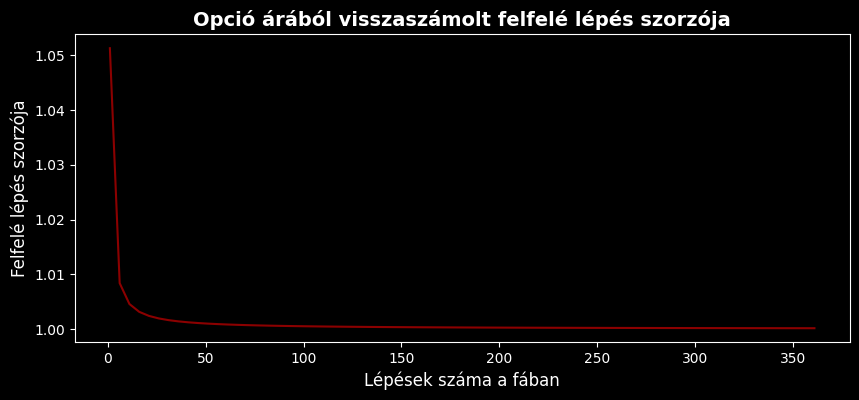

In [221]:
plt.figure(figsize=(10,4))
plt.plot(steps_list, calibrated_mult_up_values, color='darkred')
plt.title('Opció árából visszaszámolt felfelé lépés szorzója', fontsize=14, fontweight='bold')
plt.xlabel('Lépések száma a fában', fontsize=12)
plt.ylabel('Felfelé lépés szorzója', fontsize=12)

In [218]:
r = 0.05
spot = 100
steps = 1
market_price = 1
T = 1


strike_list = [99 + i for i in range(1, 22)]
calibrated_mult_up_values_2 = []

for strike in strike_list:
    dt = T/steps
    discount_factor = np.exp(-r * dt)
    mult_up = calibration_function(market_price, discount_factor, steps, spot, strike)
    calibrated_mult_up_values_2.append(mult_up)

print(calibrated_mult_up_values_2)

[1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.0512810963760242, 1.131025420334997, 1.1410254169479896, 1.1510254169275205, 1.1610254169275205, 1.1710254184716826, 1.1512710963760242, 1.1512710963760242, 1.1512710963760242, 1.1512710963760242, 1.1512710963760242]


Text(0, 0.5, 'Felfelé lépés szorzója')

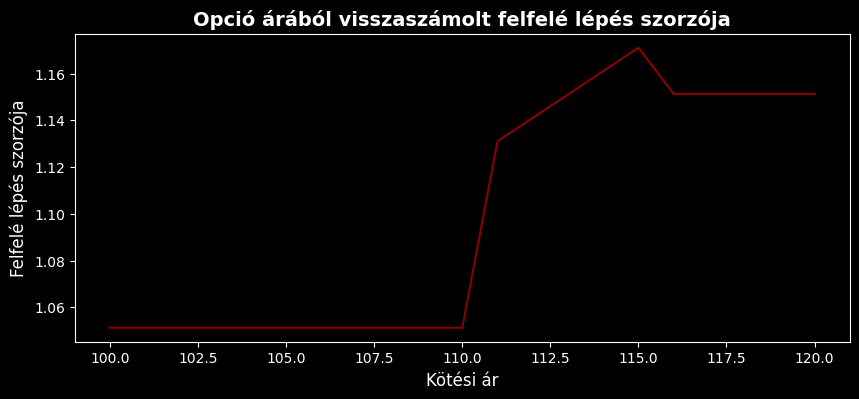

In [219]:
plt.figure(figsize=(10,4))
plt.plot(strike_list, calibrated_mult_up_values_2, color='darkred')
plt.title('Opció árából visszaszámolt felfelé lépés szorzója', fontsize=14, fontweight='bold')
plt.xlabel('Kötési ár', fontsize=12)
plt.ylabel('Felfelé lépés szorzója', fontsize=12)

In [216]:
r = 0.05
spot = 100
steps = 1
market_price = 1
strike = 100


expiry_list = [0 + i for i in range(1, 22)]
calibrated_mult_up_values_3 = []

for expiry in expiry_list:
    dt = expiry/steps
    discount_factor = np.exp(-r * dt)
    mult_up = calibration_function(market_price, discount_factor, steps, spot, strike)
    calibrated_mult_up_values_3.append(mult_up)

print(calibrated_mult_up_values_3)

[1.0512810963760242, 1.2051709180756478, 1.2618342427282832, 1.32140275816017, 1.3840254166877415, 1.4498588075760033, 1.5190675485932574, 1.5918246976412704, 1.6683121854901688, 1.7487212707001283, 1.8332530178673954, 1.9221188003905092, 2.015540829013896, 2.1137527074704767, 2.217000016612675, 2.325540928492468, 2.4396468519259913, 2.55960311115695, 2.6857096593158465, 2.818281828459045, 2.957651118063164]


Text(0, 0.5, 'Felfelé lépés szorzója')

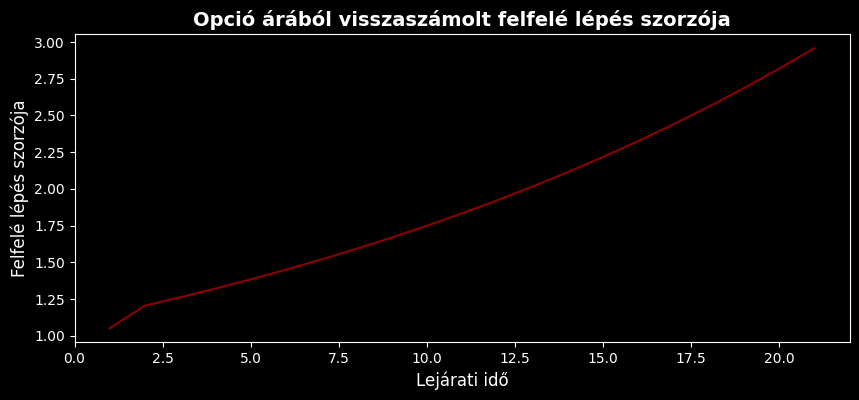

In [217]:
plt.figure(figsize=(10,4))
plt.plot(expiry_list, calibrated_mult_up_values_3, color='darkred')
plt.title('Opció árából visszaszámolt felfelé lépés szorzója', fontsize=14, fontweight='bold')
plt.xlabel('Lejárati idő', fontsize=12)
plt.ylabel('Felfelé lépés szorzója', fontsize=12)